<img src="Figures\Logos\Institutions.png" width="800px">


# Supplementary 3 — GAMM modelling of diel incubation rhythms across egg age and elevation
Author code: Jorge Lizarazo

This notebook links minute-level incubation predictions to developmental and environmental covariates and fits generalized additive mixed models to the daily rhythm of incubation behaviour. Python is used to prepare and merge the minute, daily, and external egg-age tables, while the main ecological models are fitted in R through rpy2 so that smooth temporal and environmental effects can be estimated in a single workflow. The notebook then exports summary objects, prediction surfaces, and line plots that show how incubation probability changes through the day as egg age and elevation vary. The emphasis is on describing broad ecological gradients and nest-level heterogeneity rather than reducing the system to a single summary statistic.

Pipeline:

1. Configure the local R environment and import the Python and R packages used in the workflow.
2. Load minute-level predictions, daily behavioural summaries, and the external covariate table.
3. Standardise merge keys and assemble a modelling table linking time of day, egg age, elevation, and nest identity.
4. Fit a candidate set of GAMMs and compare their support.
5. Inspect model diagnostics and retain the preferred reporting model.
6. Generate prediction surfaces across time of day, egg age, and elevation.
7. Plot line summaries for representative egg-age and elevation strata.
8. Export model summaries and figures for use in the manuscript.

In [1]:
import os

R_HOME = r"C:\Program Files\R\R-4.5.2"
R_BIN = r"C:\Program Files\R\R-4.5.2\bin\x64"

os.environ["R_HOME"] = R_HOME
os.environ["PATH"] = R_BIN + ";" + os.environ["PATH"]

os.add_dll_directory(R_BIN)

print("R_HOME:", os.environ["R_HOME"])
print("R_BIN added:", R_BIN)

R_HOME: C:\Program Files\R\R-4.5.2
R_BIN added: C:\Program Files\R\R-4.5.2\bin\x64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

base = importr("base")
stats = importr("stats")
nlme = importr("nlme")
mgcv = importr("mgcv")


Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [3]:
minute_path = r"data\minute_predictions_myioborus_calendar.csv"
summary_path = r"data\daily_summary_myioborus.csv"
sebas_path = r"data\Sebas_data.csv"

df_min = pd.read_csv(minute_path)
df_daily = pd.read_csv(summary_path)
df_sebas = pd.read_csv(sebas_path)

print(df_min.shape)
print(df_daily.shape)
print(df_sebas.shape)

print(df_min.columns.tolist())
print(df_daily.columns.tolist())
print(df_sebas.columns.tolist())

(299520, 14)
(184, 25)
(184, 22)
['#', 'tiempo', 'egg', 'ambient', 'tiempo_min', 'archivo', 'dia', 'minuto', 'prediccion', 'block_dia', 'block_minute', 'calendar_date', 'clock_minute', 'incubating']
['archivo', 'dia', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Estacion', 'Especie', 'Familia', 'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm', 'Nido_peso_Total_g', 'Altura_sobre_el_suelo_cm']
['archivo', 'dia', ' diaprox ', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Huevo_Peso_g', ' datalogercorrec ', ' edad_huevoR

In [5]:
# Clean column names
df_min.columns = df_min.columns.str.strip()
df_daily.columns = df_daily.columns.str.strip()
df_sebas.columns = df_sebas.columns.str.strip()

print("df_min columns:")
print(df_min.columns.tolist())

print("\ndf_daily columns:")
print(df_daily.columns.tolist())

print("\ndf_sebas columns:")
print(df_sebas.columns.tolist())

df_min columns:
['#', 'tiempo', 'egg', 'ambient', 'tiempo_min', 'archivo', 'dia', 'minuto', 'prediccion', 'block_dia', 'block_minute', 'calendar_date', 'clock_minute', 'incubating', 'dia_key']

df_daily columns:
['archivo', 'dia', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Estacion', 'Especie', 'Familia', 'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm', 'Nido_peso_Total_g', 'Altura_sobre_el_suelo_cm', 'dia_key']

df_sebas columns:
['archivo', 'dia', 'diaprox', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Huevo_Pe

## Building the GAMM dataset

The next blocks merge the minute-level prediction table with daily nest metadata and the external egg-age table so that time of day, egg age, elevation, station, species, and nest identity can enter the same model. This preparation step is crucial because the GAMM is only interpretable if the binary incubation response and all ecological covariates are aligned at the same nest-day resolution before downsampling and fitting begin.

In [6]:
# Build GAMM dataset: minute predictions + elevation + egg age
# Species: M. melanocephalus and M. miniatus only
# ============================================================

# Standardise keys
df_min["archivo"] = df_min["archivo"].astype(str).str.strip()
df_daily["archivo"] = df_daily["archivo"].astype(str).str.strip()
df_sebas["archivo"] = df_sebas["archivo"].astype(str).str.strip()

df_min["block_dia"] = pd.to_numeric(df_min["block_dia"], errors="coerce").astype("Int64")
df_min["dia_key"] = df_min["block_dia"]

df_daily["dia_key"] = pd.to_numeric(df_daily["dia"], errors="coerce").astype("Int64")
df_sebas["dia_key"] = pd.to_numeric(df_sebas["dia"], errors="coerce").astype("Int64")

df_sebas["diaprox"] = pd.to_numeric(df_sebas["diaprox"], errors="coerce")

# Daily metadata from daily_summary
daily_covars = df_daily[
    [
        "archivo",
        "dia_key",
        "Especie",
        "Estacion",
        "Elevacion",
        "Huevo_Peso_g",
        "ID_del_Nido",
        "equivalente"
    ]
].drop_duplicates()

# Egg age from Sebas_data
egg_age = df_sebas[
    [
        "archivo",
        "dia_key",
        "diaprox",
        "edad_huevoR",
        "Huevo_edadinversa",
        "Fenologia"
    ]
].drop_duplicates()

# Merge metadata + egg age at nest-day level
daily_covars = daily_covars.merge(
    egg_age,
    on=["archivo", "dia_key"],
    how="left"
)

print("daily_covars shape:", daily_covars.shape)
print(daily_covars.head())
print("Missing diaprox in daily_covars:", daily_covars["diaprox"].isna().sum())

daily_covars shape: (184, 12)
                                             archivo  dia_key  \
0  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        0   
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        1   
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        3   
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        4   
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        5   

                    Especie   Estacion  Elevacion  Huevo_Peso_g ID_del_Nido  \
0  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   
1  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   
2  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   
3  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   
4  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   

  equivalente  diaprox edad_huevoR Huevo_edadinversa  Fenologia  
0   TU1_DOR08        4           4    

In [7]:
# Merge daily covariates into minute-level predictions
# ============================================================

df_long = df_min.merge(
    daily_covars,
    on=["archivo", "dia_key"],
    how="left"
)

# Keep only the two target species
species_keep = [
    "Myioborus_melanocephalus",
    "Myioborus_miniatus"
]

df_long = df_long[df_long["Especie"].isin(species_keep)].copy()

# Binary response for GAMM
# prediccion: 0 = Nocturnal, 1 = Off, 2 = On
# incubating: 1 = On or Nocturnal, 0 = Off
df_long["incubating"] = np.where(df_long["prediccion"].isin([0, 2]), 1, 0)

# Numeric variables
df_long["minute_of_day"] = pd.to_numeric(df_long["clock_minute"], errors="coerce")
df_long["Elevacion"] = pd.to_numeric(df_long["Elevacion"], errors="coerce")
df_long["diaprox"] = pd.to_numeric(df_long["diaprox"], errors="coerce")
df_long["Huevo_Peso_g"] = pd.to_numeric(df_long["Huevo_Peso_g"], errors="coerce")

# Random-effect IDs
df_long["Nest_ID"] = df_long["archivo"].astype(str)
df_long["NestCalendarDay_ID"] = (
    df_long["archivo"].astype(str) + "_date_" + df_long["calendar_date"].astype(str)
)
df_long["Estacion"] = df_long["Estacion"].astype(str)

# Drop incomplete rows
df_long = df_long.dropna(
    subset=[
        "incubating",
        "minute_of_day",
        "Elevacion",
        "diaprox",
        "Huevo_Peso_g",
        "Estacion",
        "Nest_ID",
        "NestCalendarDay_ID",
        "Especie"
    ]
).copy()

df_long["incubating"] = df_long["incubating"].astype(int)
df_long["minute_of_day"] = df_long["minute_of_day"].astype(int)

print("df_long shape:", df_long.shape)

print(df_long[
    [
        "archivo", "dia", "Especie", "Estacion",
        "minute_of_day", "incubating",
        "Elevacion", "diaprox", "Huevo_Peso_g"
    ]
].head())

print("\nSpecies counts:")
print(df_long["Especie"].value_counts())

print("\nUnique nests:", df_long["Nest_ID"].nunique())
print("Unique nest-days:", df_long["NestCalendarDay_ID"].nunique())
print("Unique stations:", df_long["Estacion"].nunique())

print("\nStation counts:")
print(df_long["Estacion"].value_counts())

print("\nMissing diaprox:", df_long["diaprox"].isna().sum())
print("Missing Elevacion:", df_long["Elevacion"].isna().sum())
print("Missing Huevo_Peso_g:", df_long["Huevo_Peso_g"].isna().sum())

df_long shape: (200570, 28)
                                             archivo  dia  \
0  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   

                    Especie   Estacion  minute_of_day  incubating  Elevacion  \
0  Myioborus_melanocephalus  San_Pedro              0           1     2263.0   
1  Myioborus_melanocephalus  San_Pedro              1           1     2263.0   
2  Myioborus_melanocephalus  San_Pedro              2           1     2263.0   
3  Myioborus_melanocephalus  San_Pedro              3           1     2263.0   
4  Myioborus_melanocephalus  San_Pedro              4           1     2263.0   

   diaprox  Huevo_Peso_g  
0      4.0          1.85  
1      4.0          1.85  
2      4.0          1.85  
3      4.0      

Complete calendar nest-days: 134
Incomplete calendar nest-days: 11
Raster matrix shape: (134, 1440)


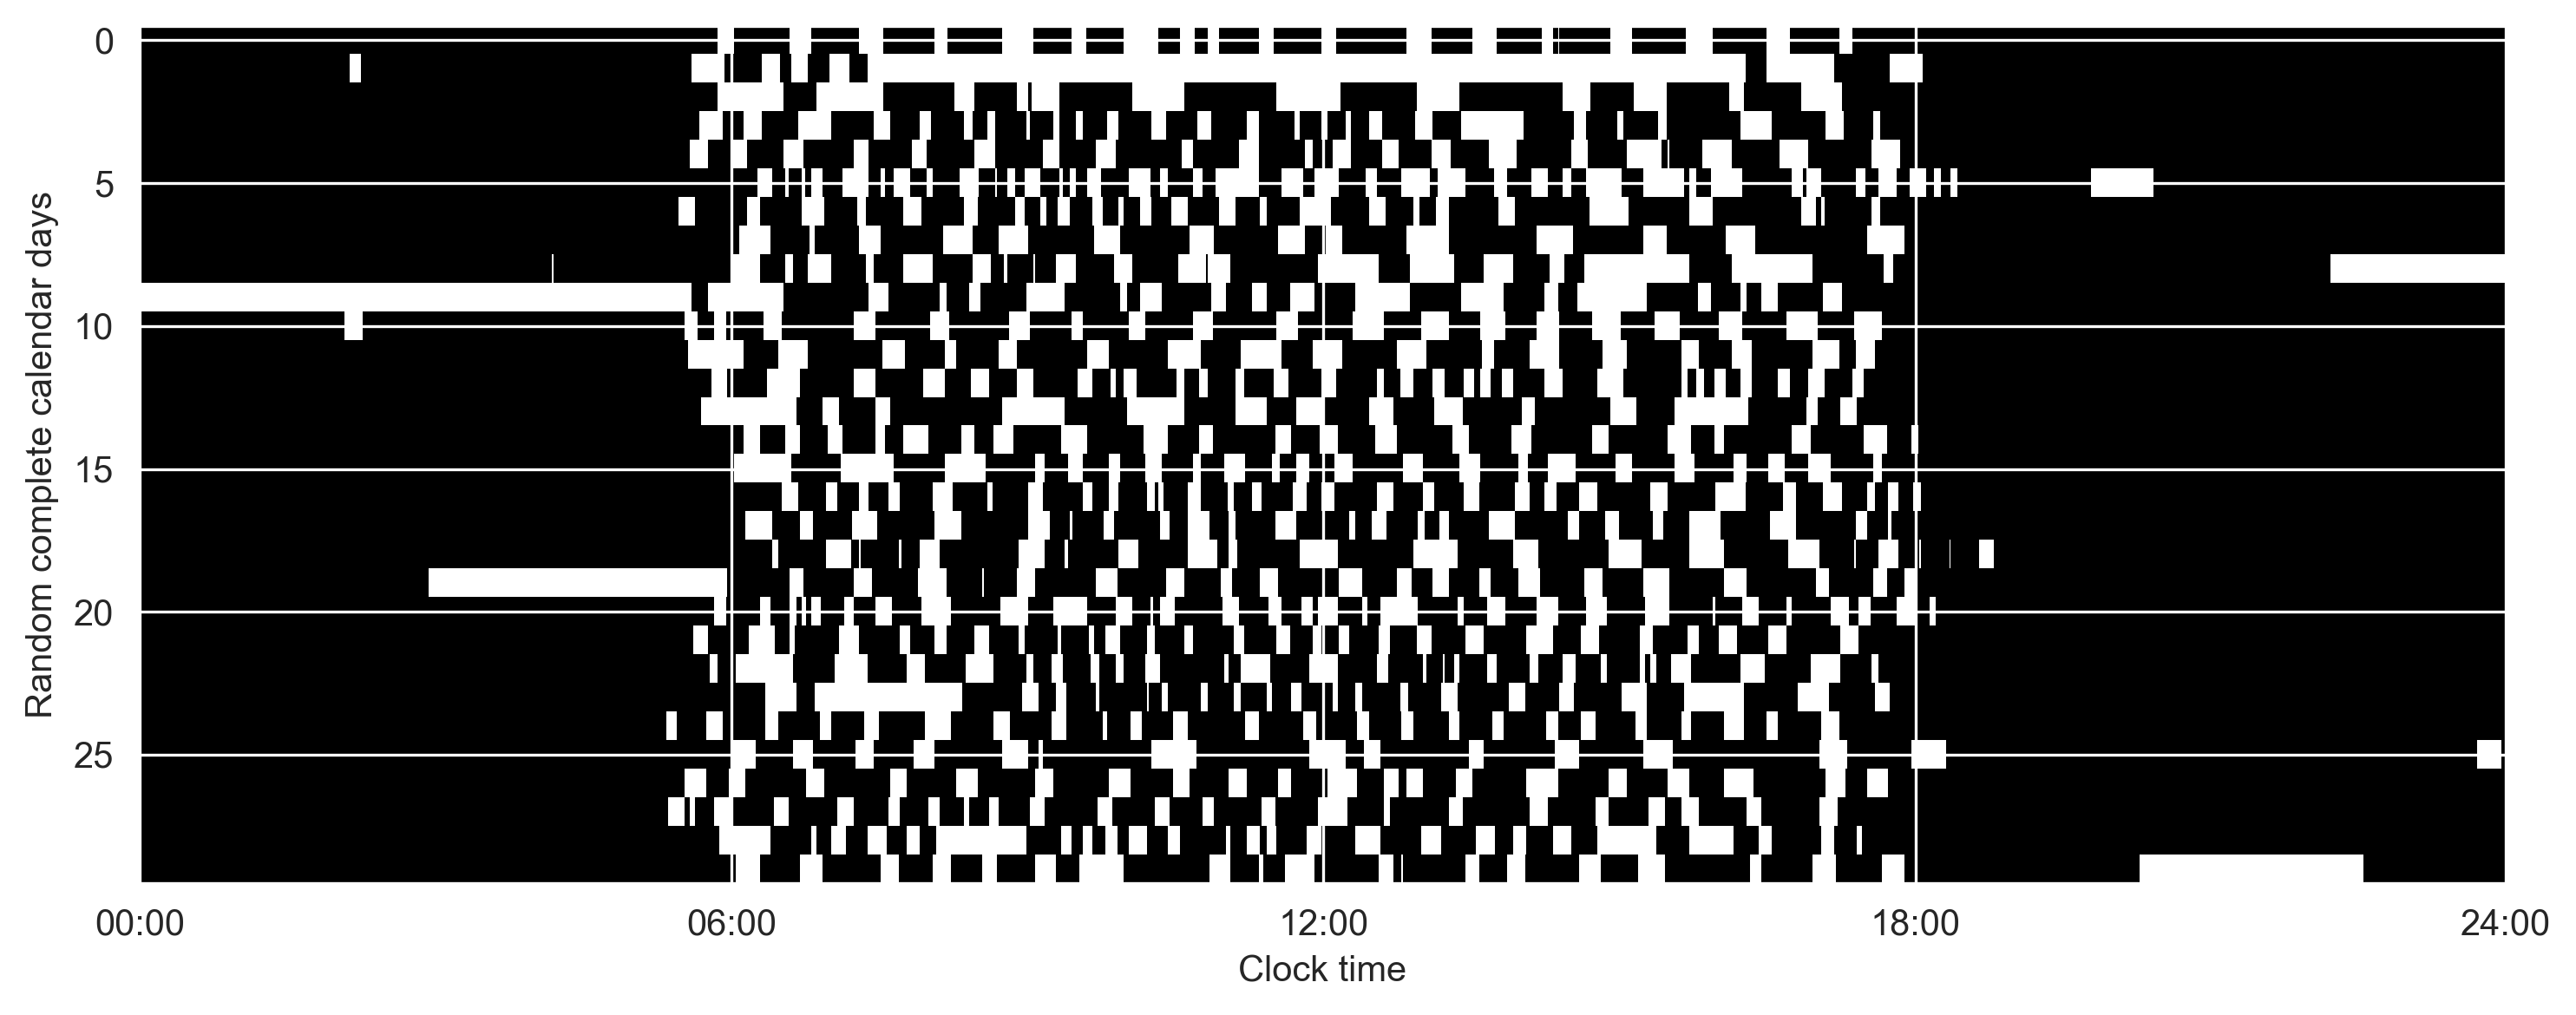

In [7]:
# ============================================================
# Observed binary rhythm raster
# 1 = On + Nocturnal
# 0 = Off
# ============================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_raster = df_long[["Nest_ID", "calendar_date", "minute_of_day", "incubating"]].copy()

df_raster["minute_of_day"] = pd.to_numeric(df_raster["minute_of_day"], errors="coerce")
df_raster["incubating"] = pd.to_numeric(df_raster["incubating"], errors="coerce")

df_raster = df_raster[df_raster["minute_of_day"].between(0, 1439)].copy()

df_raster["minute_of_day"] = df_raster["minute_of_day"].astype(int)
df_raster["incubating"] = df_raster["incubating"].astype(int)

df_raster = (
    df_raster
    .sort_values(["Nest_ID", "calendar_date", "minute_of_day"])
    .drop_duplicates(subset=["Nest_ID", "calendar_date", "minute_of_day"], keep="first")
)

counts = (
    df_raster
    .groupby(["Nest_ID", "calendar_date"])["minute_of_day"]
    .nunique()
)

complete_keys = counts[counts == 1440].index

print("Complete calendar nest-days:", len(complete_keys))
print("Incomplete calendar nest-days:", (counts < 1440).sum())

df_complete = (
    df_raster
    .set_index(["Nest_ID", "calendar_date"])
    .loc[complete_keys]
    .reset_index()
)

matrix_df = df_complete.pivot(
    index=["Nest_ID", "calendar_date"],
    columns="minute_of_day",
    values="incubating"
)

matrix_df = matrix_df.reindex(columns=range(1440)).dropna()

print("Raster matrix shape:", matrix_df.shape)

n_days = 30
matrix_df_plot = matrix_df.sample(
    n=min(n_days, len(matrix_df)),
    random_state=42
)

matrix = matrix_df_plot.to_numpy()

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

ax.imshow(
    matrix,
    aspect="auto",
    cmap="binary",
    interpolation="nearest",
    vmin=0,
    vmax=1
)

ax.set_xlabel("Clock time")
ax.set_ylabel("Random complete calendar days")

ax.set_xticks([0, 360, 720, 1080, 1439])
ax.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Downsample to 2-minute resolution for GAMM speed
# ============================================================

df_long_2min = df_long[df_long["minute_of_day"] % 2 == 0].reset_index(drop=True)

print("df_long_2min shape:", df_long_2min.shape)

print(df_long_2min[
    [
        "archivo", "calendar_date", "dia_key", "Especie", "Estacion",
        "minute_of_day", "incubating",
        "Elevacion", "diaprox", "Huevo_Peso_g"
    ]
].head())

print("\nUnique nests:", df_long_2min["Nest_ID"].nunique())
print("Unique calendar nest-days:", df_long_2min["NestCalendarDay_ID"].nunique())
print("Unique stations:", df_long_2min["Estacion"].nunique())

print("\nStation counts:")
print(df_long_2min["Estacion"].value_counts())

df_long_2min shape: (100284, 28)
                                             archivo calendar_date  dia_key  \
0  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   

                    Especie   Estacion  minute_of_day  incubating  Elevacion  \
0  Myioborus_melanocephalus  San_Pedro              0           1     2263.0   
1  Myioborus_melanocephalus  San_Pedro              2           1     2263.0   
2  Myioborus_melanocephalus  San_Pedro              4           1     2263.0   
3  Myioborus_melanocephalus  San_Pedro              6           1     2263.0   
4  Myioborus_melanocephalus  San_Pedro              8           1     2263.0   

   diaprox 

In [9]:
# ============================================================
# Prepare clean GAMM dataframe
# ============================================================

cols_for_gamm = [
    "incubating",
    "minute_of_day",
    "Elevacion",
    "diaprox",
    "Huevo_Peso_g",
    "Especie",
    "Estacion",
    "Nest_ID",
    "NestCalendarDay_ID"
]

df_gamm = df_long_2min[cols_for_gamm].copy()

df_gamm["incubating"] = df_gamm["incubating"].astype(int)
df_gamm["minute_of_day"] = df_gamm["minute_of_day"].astype(int)

df_gamm["Elevacion"] = pd.to_numeric(df_gamm["Elevacion"], errors="coerce")
df_gamm["diaprox"] = pd.to_numeric(df_gamm["diaprox"], errors="coerce")
df_gamm["Huevo_Peso_g"] = pd.to_numeric(df_gamm["Huevo_Peso_g"], errors="coerce")

for col in ["Especie", "Estacion", "Nest_ID", "NestCalendarDay_ID"]:
    df_gamm[col] = df_gamm[col].astype(str)

df_gamm = df_gamm.dropna().reset_index(drop=True)

print(df_gamm.dtypes)
print(df_gamm.shape)

incubating              int64
minute_of_day           int64
Elevacion             float64
diaprox               float64
Huevo_Peso_g          float64
Especie                object
Estacion               object
Nest_ID                object
NestCalendarDay_ID     object
dtype: object
(100284, 9)


In [10]:
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv["df_long"] = df_gamm

In [11]:
ro.r("""
library(mgcv)

df_long$Estacion <- as.factor(df_long$Estacion)
df_long$Nest_ID <- as.factor(df_long$Nest_ID)
df_long$NestCalendarDay_ID <- as.factor(df_long$NestCalendarDay_ID)
df_long$Especie <- as.factor(df_long$Especie)

cat("Rows:", nrow(df_long), "\\n")
cat("Nests:", length(unique(df_long$Nest_ID)), "\\n")
cat("Calendar nest-days:", length(unique(df_long$NestCalendarDay_ID)), "\\n")
cat("Species:", levels(df_long$Especie), "\\n")
cat("Stations:", levels(df_long$Estacion), "\\n")
""")

Rows: 100284 
Nests: 32 
Calendar nest-days: 145 
Species: Myioborus_melanocephalus Myioborus_miniatus 
Stations: San_Pedro Tatama Wayquecha 


In [13]:
ro.r("""
model_full <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(Elevacion, k = 6) +
    s(diaprox, k = 6) +
    s(Huevo_Peso_g, k = 5) +
    ti(minute_of_day, Elevacion, bs = c("cc", "tp"), k = c(20, 6)) +
    ti(minute_of_day, diaprox, bs = c("cc", "tp"), k = c(20, 6)) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_full))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(Elevacion, k = 6) + s(diaprox, k = 6) + s(Huevo_Peso_g, 
    k = 5) + ti(minute_of_day, Elevacion, bs = c("cc", "tp"), 
    k = c(20, 6)) + ti(minute_of_day, diaprox, bs = c("cc", "tp"), 
    k = c(20, 6)) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 3.9098     0.6747   5.795 6.85e-09 ***
EspecieMyioborus_miniatus  -0.1069     0.6048  -0.177    0.860    
EstacionTatama              0.0493     0.2705   0.182    0.855    
EstacionWayquecha           0.1932     1.6500   0.117    0.907    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                               edf Ref.df   Chi.sq  p-value    
s(minute_of_day)            16.888 18.000 2052.513  < 2e-16 ***
s(Elevacion)                 3.560  3.633

In [12]:
ro.r("""
model_no_eggmass <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(Elevacion, k = 6) +
    s(diaprox, k = 6) +
    ti(minute_of_day, Elevacion, bs = c("cc", "tp"), k = c(20, 6)) +
    ti(minute_of_day, diaprox, bs = c("cc", "tp"), k = c(20, 6)) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_no_eggmass))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(Elevacion, k = 6) + s(diaprox, k = 6) + ti(minute_of_day, 
    Elevacion, bs = c("cc", "tp"), k = c(20, 6)) + ti(minute_of_day, 
    diaprox, bs = c("cc", "tp"), k = c(20, 6)) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                4.00234    0.62014   6.454 1.09e-10 ***
EspecieMyioborus_miniatus -0.20662    0.52872  -0.391    0.696    
EstacionTatama             0.05814    0.26431   0.220    0.826    
EstacionWayquecha          0.10802    1.61499   0.067    0.947    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                               edf Ref.df  Chi.sq  p-value    
s(minute_of_day)            16.889 18.000 2048.92  < 2e-16 ***
s(Elevacion)                 3.586  3.660   48.66 6.01e-07 ***
s(diaprox)

In [14]:
ro.r("""
model_no_elev_interaction <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(Elevacion, k = 6) +
    s(diaprox, k = 6) +
    ti(minute_of_day, diaprox, bs = c("cc", "tp"), k = c(20, 6)) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_no_elev_interaction))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(Elevacion, k = 6) + s(diaprox, k = 6) + ti(minute_of_day, 
    diaprox, bs = c("cc", "tp"), k = c(20, 6)) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                3.03953    0.46438   6.545 5.94e-11 ***
EspecieMyioborus_miniatus -0.22071    0.46096  -0.479    0.632    
EstacionTatama            -0.04979    0.27290  -0.182    0.855    
EstacionWayquecha         -0.16624    0.79063  -0.210    0.833    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                             edf Ref.df   Chi.sq p-value    
s(minute_of_day)          16.814 18.000 2451.923  <2e-16 ***
s(Elevacion)               1.463  1.469    0.114   0.856    
s(diaprox)                 4.944  4.979  217.971  <2e-16 ***
ti(diaprox,minute_of_day)

In [15]:
ro.r("""
model_no_elev <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(diaprox, k = 6) +
    ti(minute_of_day, diaprox, bs = c("cc", "tp"), k = c(20, 6)) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_no_elev))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(diaprox, k = 6) + ti(minute_of_day, diaprox, 
    bs = c("cc", "tp"), k = c(20, 6)) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                3.03630    0.42046   7.221 5.15e-13 ***
EspecieMyioborus_miniatus -0.15474    0.41661  -0.371    0.710    
EstacionTatama            -0.10006    0.26059  -0.384    0.701    
EstacionWayquecha         -0.03361    0.41650  -0.081    0.936    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                             edf Ref.df Chi.sq p-value    
s(minute_of_day)          16.758 18.000 2441.6  <2e-16 ***
s(diaprox)                 4.944  4.979  217.5  <2e-16 ***
ti(diaprox,minute_of_day) 78.158 90.000  823.1  <2e-16 ***
s(Nest_ID)                27.428 29.000 1395.1  <2e-16 

In [16]:
ro.r("""
model_main_only <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(diaprox, k = 6) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_main_only))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(diaprox, k = 6) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                2.15677    0.40678   5.302 1.15e-07 ***
EspecieMyioborus_miniatus -0.16812    0.41252  -0.408    0.684    
EstacionTatama            -0.09224    0.25801  -0.357    0.721    
EstacionWayquecha         -0.03477    0.41241  -0.084    0.933    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                    edf Ref.df  Chi.sq p-value    
s(minute_of_day) 17.595 18.000 16601.9   0.816    
s(diaprox)        4.935  4.998   290.3  <2e-16 ***
s(Nest_ID)       27.435 28.000 17141.4  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =   0.18   Deviance explained = 21.1%
fREML = 1.321e+05  Scale est. = 1     

In [17]:
ro.r("""
model_comparison <- AIC(
  model_full,
  model_no_eggmass,
  model_no_elev_interaction,
  model_no_elev,
  model_main_only
)

print(model_comparison)

delta_AIC <- model_comparison$AIC - min(model_comparison$AIC)
model_comparison$delta_AIC <- delta_AIC

print(model_comparison[order(model_comparison$AIC), ])
""")

                                 df      AIC
model_full                205.63809 76798.48
model_no_eggmass          205.57910 76798.86
model_no_elev_interaction 132.81722 78624.24
model_no_elev             132.68914 78626.21
model_main_only            54.25205 79669.64
                                 df      AIC    delta_AIC
model_full                205.63809 76798.48    0.0000000
model_no_eggmass          205.57910 76798.86    0.3833029
model_no_elev_interaction 132.81722 78624.24 1825.7683982
model_no_elev             132.68914 78626.21 1827.7364371
model_main_only            54.25205 79669.64 2871.1674277


In [18]:
ro.r("""
gam.check(model_no_eggmass)
""")


Method: fREML   Optimizer: perf chol
$grad
[1] 1.678731e-06 5.418849e-07 9.626312e-08 1.651459e-06 1.789293e-05
[6] 1.575611e-06 7.267060e-06 3.394227e-07

$hess
             [,1]         [,2]         [,3]        [,4]        [,5]        [,6]
[1,]  6.738232705 -0.003410748 -0.024304747  0.07398967 -1.62083912 -0.38352517
[2,] -0.003410748  1.411808310 -0.001933247 -0.21941256 -0.24985951 -0.01302451
[3,] -0.024304747 -0.001933247  1.876922044 -0.01749629 -0.02909163 -0.51759567
[4,]  0.073989672 -0.219412555 -0.017496293  3.05554146 -0.10586347 -0.08692525
[5,] -1.620839116 -0.249859507 -0.029091626 -0.10586347 10.43661470 -0.22407213
[6,] -0.383525166 -0.013024510 -0.517595671 -0.08692525 -0.22407213 10.41811899
[7,] -1.563734773 -0.007947975 -0.420978117 -0.10109280 -0.22247231 -2.03505410
[8,] -0.003065322 -0.124325963 -0.026367024 -0.07854159 -0.12531378 -0.11728022
             [,7]         [,8]
[1,] -1.563734773 -0.003065322
[2,] -0.007947975 -0.124325963
[3,] -0.420978117 -0.026

In [19]:
ro.r("""
concurvity(model_no_eggmass, full = TRUE)
""")

1.000000,1.000000,1.000000,...,1.000000,0.206192,0.397722


In [18]:
ro.r("""
sink("data/GAMM_preferred_model_no_eggmass_summary.txt")

cat("MODEL COMPARISON\\n")
print(model_comparison[order(model_comparison$AIC), ])

cat("\\n\\nPREFERRED MODEL: model_no_eggmass\\n")
print(summary(model_no_eggmass))

cat("\\n\\nGAM CHECK\\n")
print(gam.check(model_no_eggmass))

cat("\\n\\nCONCURVITY\\n")
print(concurvity(model_no_eggmass, full = TRUE))

sink()
""")

## Preferred model selection

The exported comparison ranks the full model and `model_no_eggmass` almost identically, with a delta AIC of only 0.38 between them. The notebook therefore carries forward the no-egg-mass formulation as the preferred reporting model because it preserves the same temporal and ecological structure while avoiding an additional smooth with minimal support. In that preferred model, incubation probability varies strongly with time of day, elevation, egg age, both time-varying interactions, and nest identity, and the fitted GAMM explains 24.2% of deviance across 100,284 two-minute records.

## Prediction surfaces from the preferred model

The remaining sections translate the preferred GAMM into surfaces and line summaries that are easier to inspect biologically. The goal is not to over-read small local undulations, but to visualise how the daily incubation rhythm shifts across egg age and elevation while the remaining covariates are held at representative values.

In [21]:
ro.r("""
library(mgcv)

# -----------------------------
# Reference values
# -----------------------------
ref_species <- names(sort(table(df_long$Especie), decreasing = TRUE))[1]
ref_station <- names(sort(table(df_long$Estacion), decreasing = TRUE))[1]
ref_nest <- levels(df_long$Nest_ID)[1]

ref_elev <- median(df_long$Elevacion, na.rm = TRUE)
ref_diaprox <- median(df_long$diaprox, na.rm = TRUE)

# Sequences for surfaces
minute_seq <- 0:1439
elev_seq <- seq(
  min(df_long$Elevacion, na.rm = TRUE),
  max(df_long$Elevacion, na.rm = TRUE),
  length.out = 60
)
diaprox_seq <- seq(
  min(df_long$diaprox, na.rm = TRUE),
  max(df_long$diaprox, na.rm = TRUE),
  length.out = 50
)

# -----------------------------
# Surface 1: minute_of_day x diaprox
# Elevation fixed at median
# -----------------------------
pred_surface_diaprox <- expand.grid(
  minute_of_day = minute_seq,
  diaprox = diaprox_seq
)

pred_surface_diaprox$Elevacion <- ref_elev
pred_surface_diaprox$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_surface_diaprox$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_surface_diaprox$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

pred_surface_diaprox$fit <- predict(
  model_no_eggmass,
  newdata = pred_surface_diaprox,
  type = "response",
  exclude = "s(Nest_ID)"
)

# -----------------------------
# Surface 2: minute_of_day x Elevacion
# Egg age fixed at median
# -----------------------------
pred_surface_elev <- expand.grid(
  minute_of_day = minute_seq,
  Elevacion = elev_seq
)

pred_surface_elev$diaprox <- ref_diaprox
pred_surface_elev$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_surface_elev$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_surface_elev$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

pred_surface_elev$fit <- predict(
  model_no_eggmass,
  newdata = pred_surface_elev,
  type = "response",
  exclude = "s(Nest_ID)"
)

# -----------------------------
# Line plot 1: 3 egg-age levels
# -----------------------------
dia_levels <- as.numeric(quantile(df_long$diaprox, probs = c(0.1, 0.5, 0.9), na.rm = TRUE))
dia_labels <- c("Low egg age", "Mid egg age", "High egg age")

pred_lines_diaprox <- expand.grid(
  minute_of_day = minute_seq,
  diaprox = dia_levels
)

pred_lines_diaprox$Elevacion <- ref_elev
pred_lines_diaprox$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_lines_diaprox$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_lines_diaprox$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

p_dia <- predict(
  model_no_eggmass,
  newdata = pred_lines_diaprox,
  type = "link",
  se.fit = TRUE,
  exclude = "s(Nest_ID)"
)

pred_lines_diaprox$fit <- plogis(p_dia$fit)
pred_lines_diaprox$lower <- plogis(p_dia$fit - 1.96 * p_dia$se.fit)
pred_lines_diaprox$upper <- plogis(p_dia$fit + 1.96 * p_dia$se.fit)
pred_lines_diaprox$group <- factor(
  rep(dia_labels, each = length(minute_seq)),
  levels = dia_labels
)

# -----------------------------
# Line plot 2: 3 elevation levels
# -----------------------------
elev_levels <- as.numeric(quantile(df_long$Elevacion, probs = c(0.1, 0.5, 0.9), na.rm = TRUE))
elev_labels <- c("Low elevation", "Mid elevation", "High elevation")

pred_lines_elev <- expand.grid(
  minute_of_day = minute_seq,
  Elevacion = elev_levels
)

pred_lines_elev$diaprox <- ref_diaprox
pred_lines_elev$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_lines_elev$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_lines_elev$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

p_elev <- predict(
  model_no_eggmass,
  newdata = pred_lines_elev,
  type = "link",
  se.fit = TRUE,
  exclude = "s(Nest_ID)"
)

pred_lines_elev$fit <- plogis(p_elev$fit)
pred_lines_elev$lower <- plogis(p_elev$fit - 1.96 * p_elev$se.fit)
pred_lines_elev$upper <- plogis(p_elev$fit + 1.96 * p_elev$se.fit)
pred_lines_elev$group <- factor(
  rep(elev_labels, each = length(minute_seq)),
  levels = elev_labels
)
""")

In [22]:
with localconverter(ro.default_converter + pandas2ri.converter):
    pred_surface_diaprox = ro.conversion.rpy2py(ro.r("pred_surface_diaprox"))
    pred_surface_elev = ro.conversion.rpy2py(ro.r("pred_surface_elev"))
    pred_lines_diaprox = ro.conversion.rpy2py(ro.r("pred_lines_diaprox"))
    pred_lines_elev = ro.conversion.rpy2py(ro.r("pred_lines_elev"))

print(pred_surface_diaprox.head())
print(pred_surface_elev.head())
print(pred_lines_diaprox.head())
print(pred_lines_elev.head())

   minute_of_day  diaprox  Elevacion             Especie Estacion  \
1              0      1.0     1684.0  Myioborus_miniatus   Tatama   
2              1      1.0     1684.0  Myioborus_miniatus   Tatama   
3              2      1.0     1684.0  Myioborus_miniatus   Tatama   
4              3      1.0     1684.0  Myioborus_miniatus   Tatama   
5              4      1.0     1684.0  Myioborus_miniatus   Tatama   

                                             Nest_ID       fit  
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999994  
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999993  
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999993  
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999992  
5  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999990  
   minute_of_day  Elevacion  diaprox             Especie Estacion  \
1              0     1356.0      6.0  Myioborus_miniatus   Tatama   
2              1     1356.0      6.0  Myioborus_miniatus 

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_surface_heatmap(pred_df, y_col, ylabel, outpath):
    heat_df = pred_df.pivot(index=y_col, columns="minute_of_day", values="fit")
    heat_df = heat_df.sort_index()

    Z = heat_df.values
    x1 = heat_df.columns.values
    y1 = heat_df.index.values

    X1, Y1 = np.meshgrid(x1, y1)

    center = np.percentile(Z, 30)
    norm = TwoSlopeNorm(vmin=0, vcenter=center, vmax=1)

    plt.figure(figsize=(12, 5), dpi=300)

    im = plt.imshow(
        Z,
        aspect='auto',
        origin='lower',
        cmap='seismic',
        interpolation='bilinear',
        norm=norm,
        extent=[x1.min(), x1.max(), y1.min(), y1.max()]
    )

    contours = plt.contour(
        X1,
        Y1,
        Z,
        colors='black',
        linewidths=0.4
    )

    plt.clabel(contours, inline=True, fontsize=9, fmt="%.2f")

    # Ticks del eje x como reloj
    plt.xticks(
        [0, 360, 720, 1080, 1439],
        ["00:00", "06:00", "12:00", "18:00", "24:00"],
        fontsize=12
    )

    plt.xlabel("Time of day", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    cbar = plt.colorbar(im)
    cbar.set_label("Probability of incubation", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_ticks([0, center, 1])
    cbar.set_ticklabels(["Low", "Mid", "High"])

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.8)

    ax.tick_params(axis='both', colors='black', labelsize=12)
    ax.grid(axis='y', alpha=0.2)

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

### Time of day × egg age

This surface holds elevation at a representative value and asks how the diel shape of incubation probability changes as egg age increases. Broad, repeated gradients in colour or contour position are more informative here than small local fluctuations.

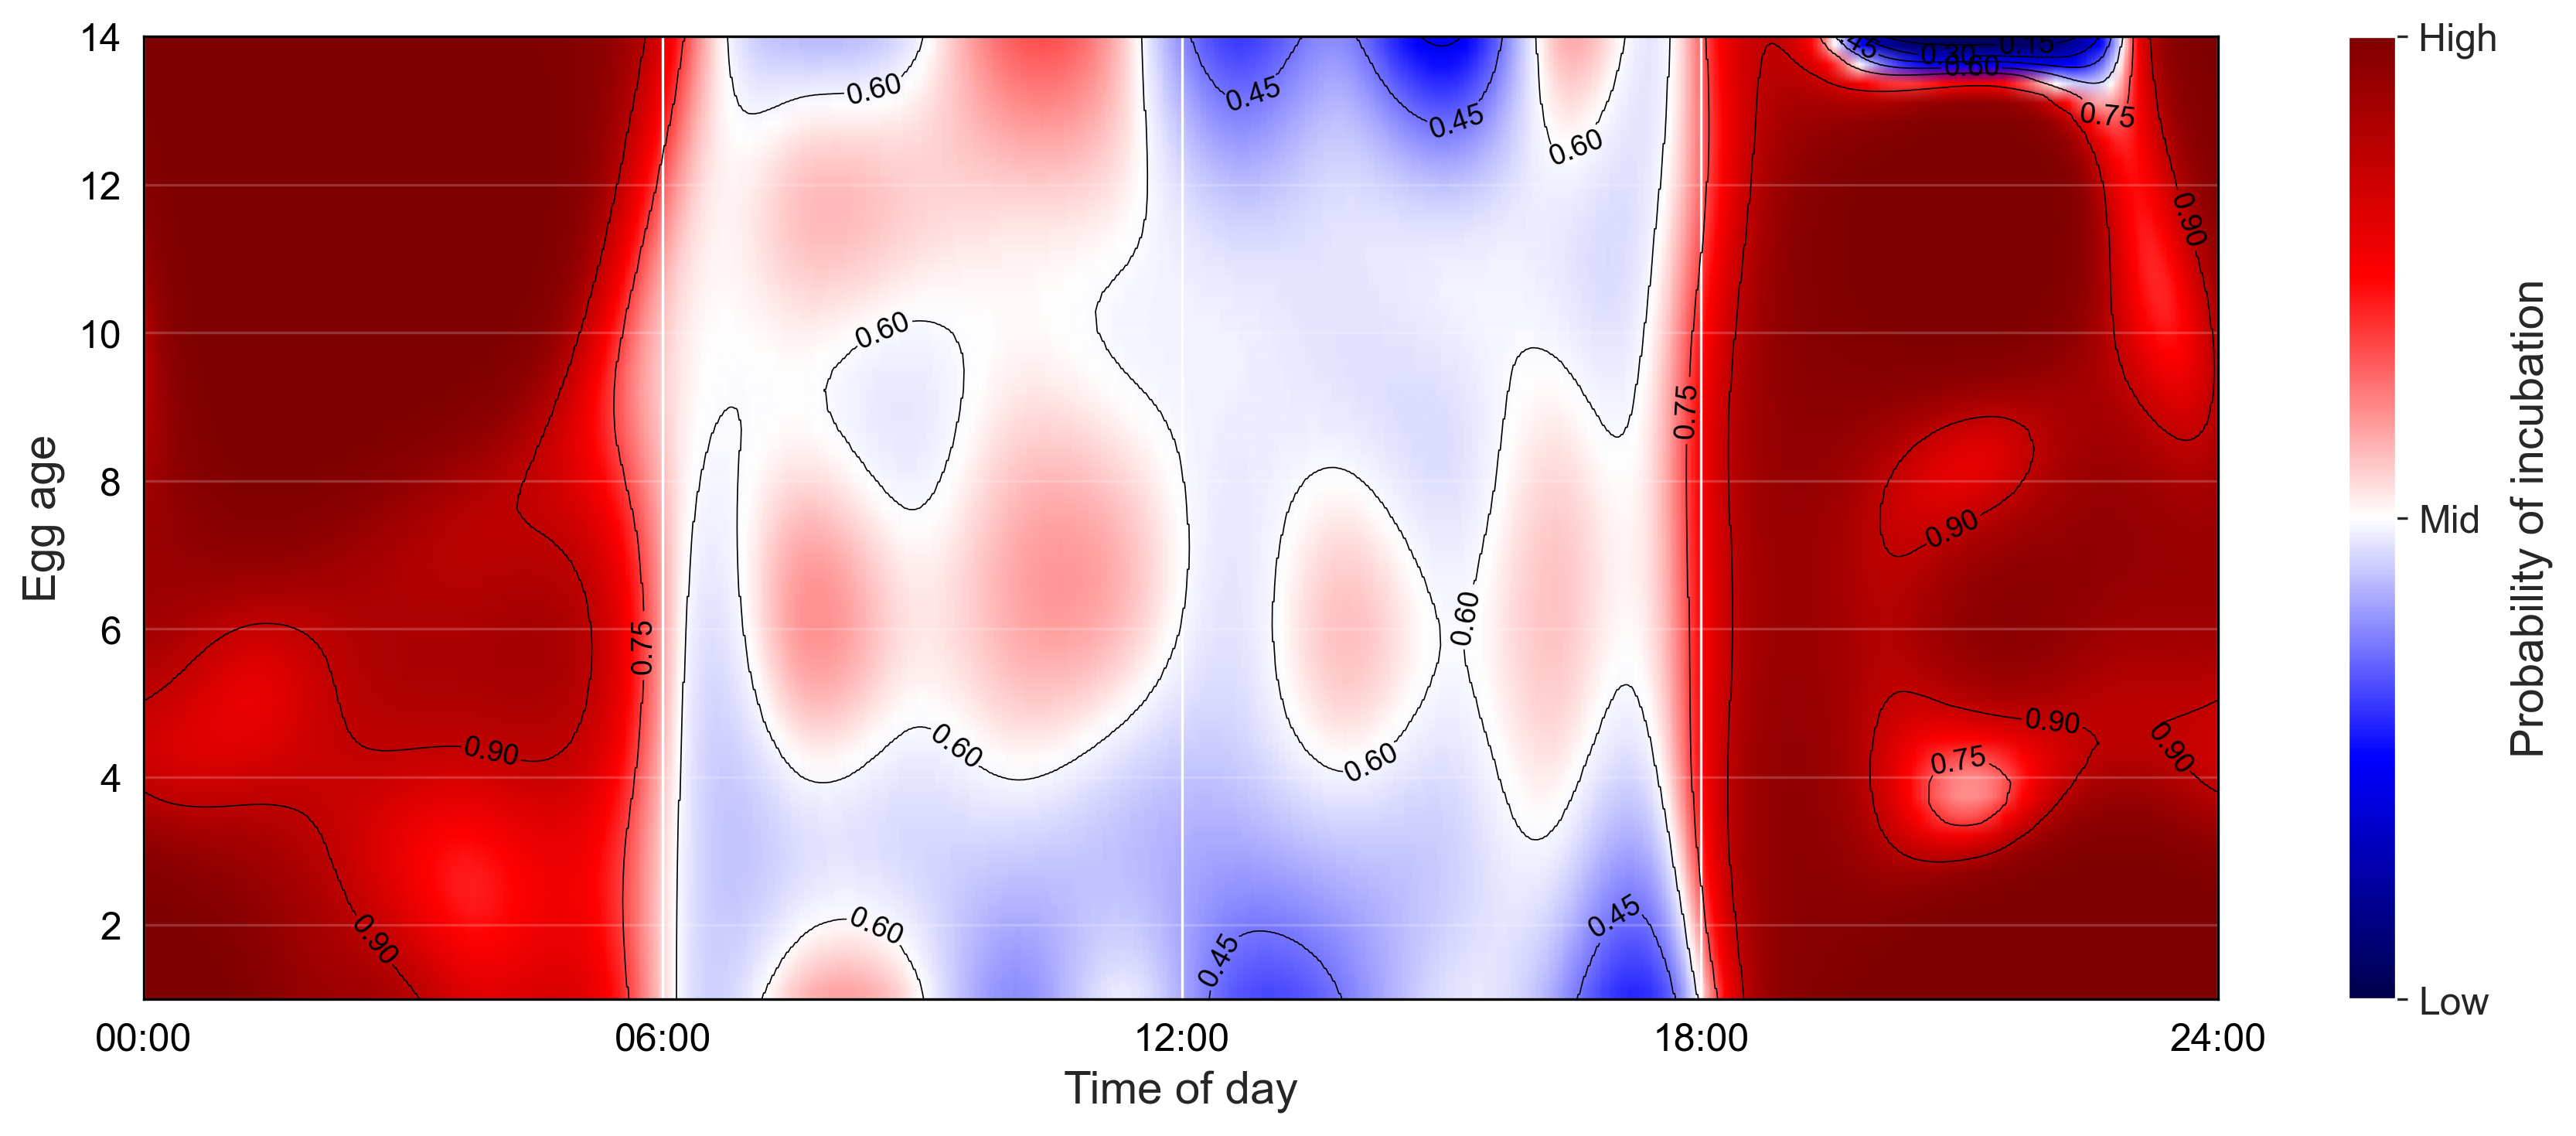

In [24]:
plot_surface_heatmap(
    pred_surface_diaprox,
    y_col="diaprox",
    ylabel="Egg age",
    outpath="Figures/GAMM_surface_time_x_eggage.png"
)

### Time of day × elevation

This companion surface fixes egg age at a representative value and shows how the daily rhythm shifts along the elevational gradient. Together with the previous panel, it reveals whether temporal structure is stable across sites or changes systematically with the environment.

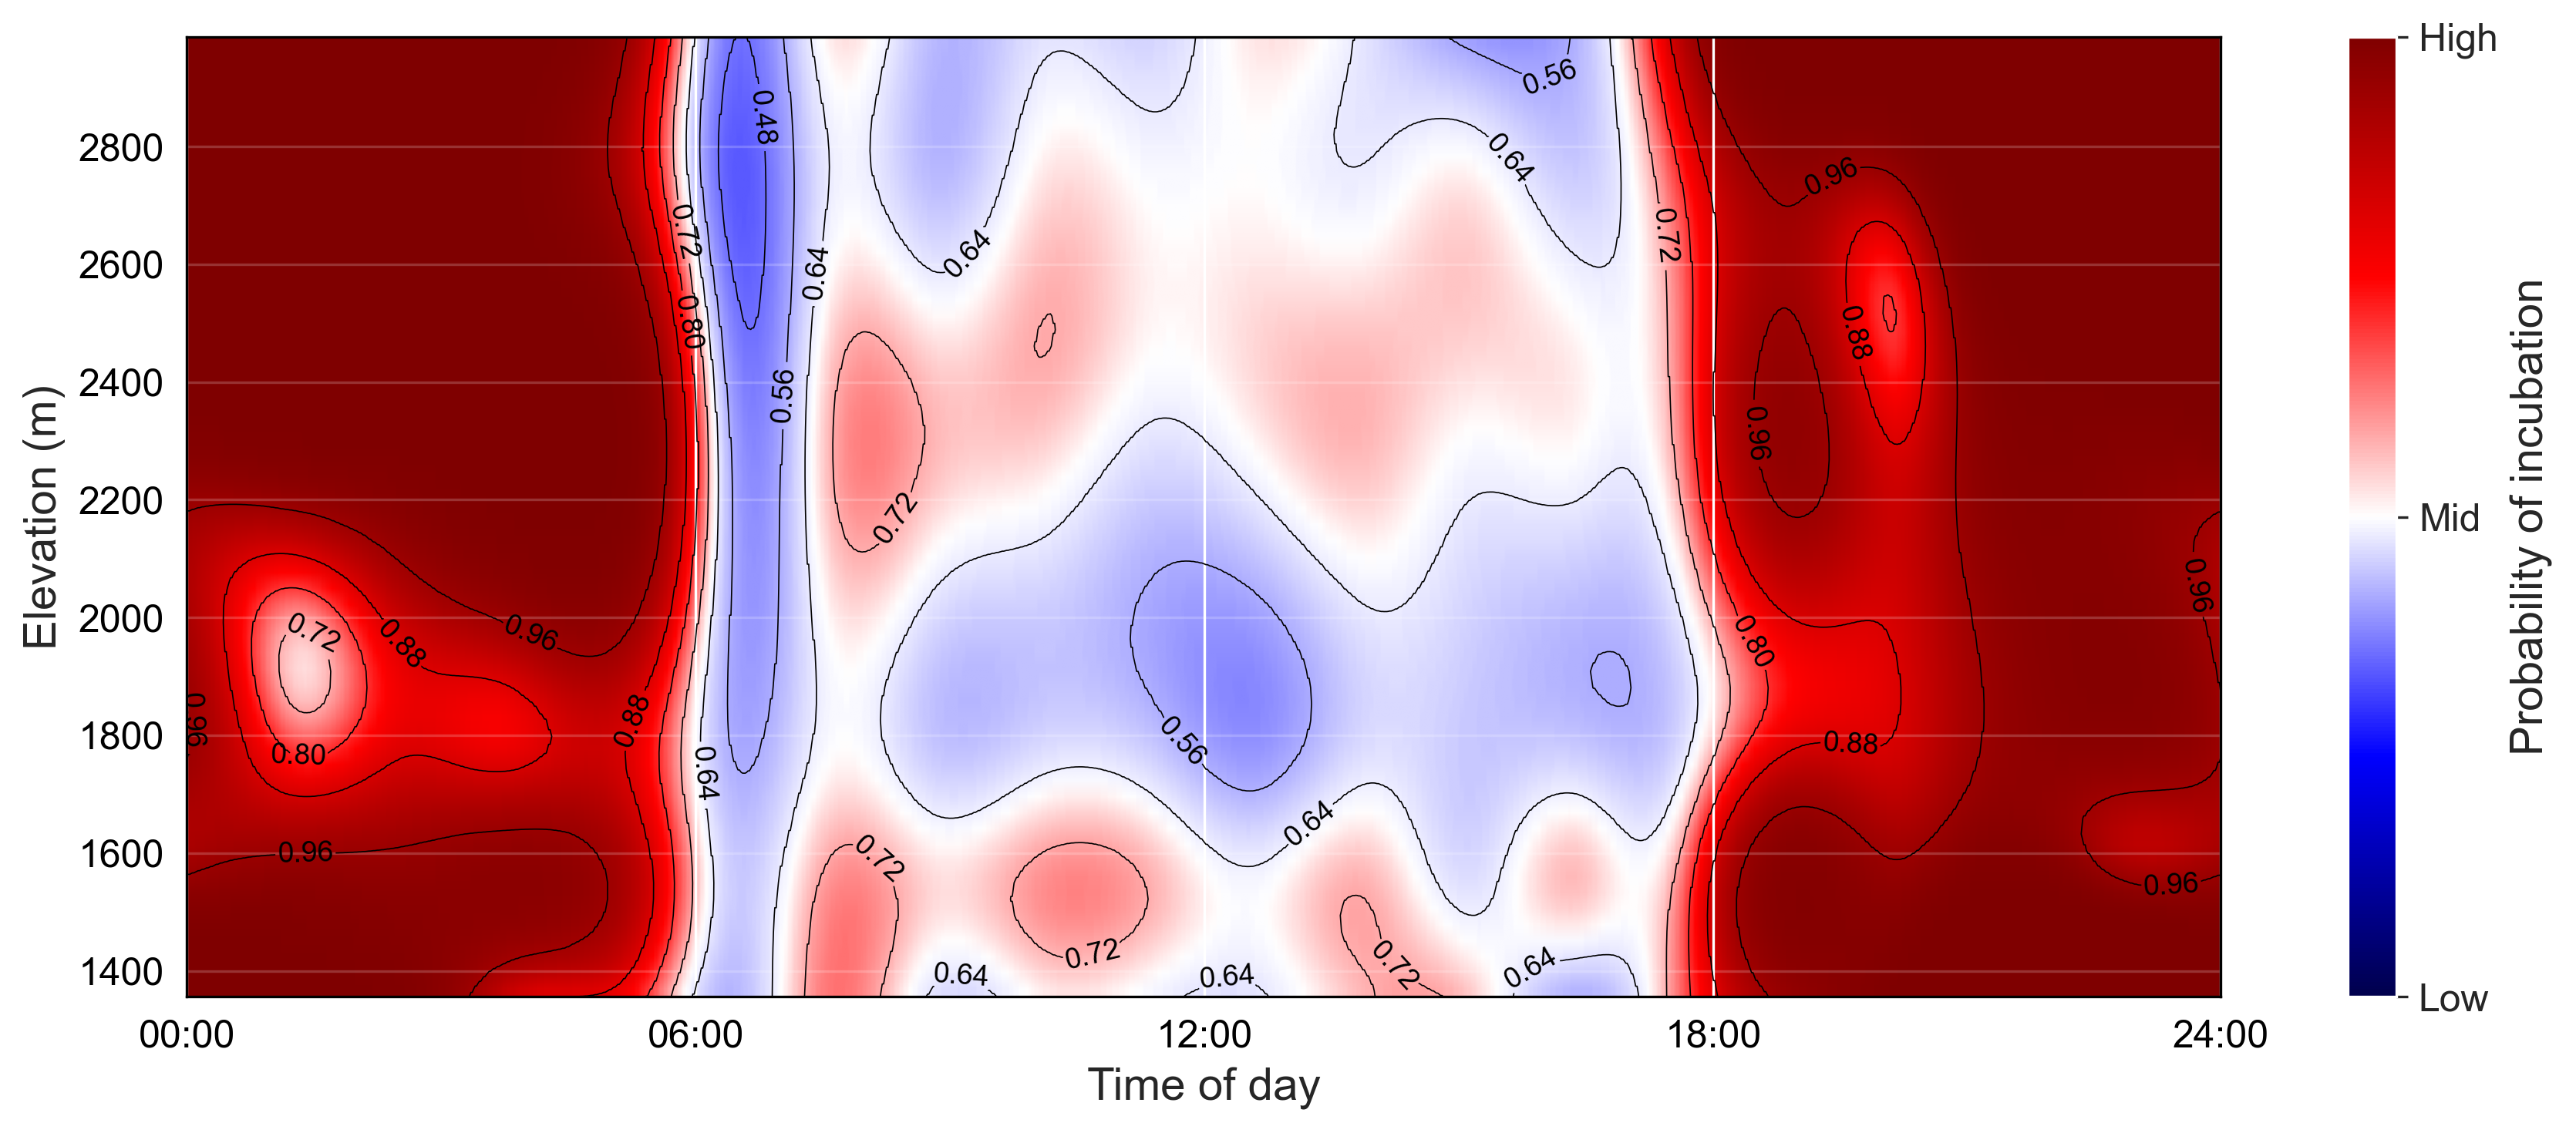

In [25]:
plot_surface_heatmap(
    pred_surface_elev,
    y_col="Elevacion",
    ylabel="Elevation (m)",
    outpath="Figures/GAMM_surface_time_x_elevation.png"
)

The two surfaces above should be read jointly: the strongest structure comes from nonlinear daily timing, but both elevation and egg age reshape that daily pattern rather than acting only as constant offsets. That is why both interaction smooths are retained in the preferred model.

In [26]:
ro.r("""
# -----------------------------
# Line plot 1: 5 egg-age levels
# -----------------------------
dia_levels <- as.numeric(quantile(
  df_long$diaprox,
  probs = c(0.1, 0.3, 0.5, 0.7, 0.9),
  na.rm = TRUE
))

dia_labels <- paste0("Egg age = ", round(dia_levels, 1))

pred_lines_diaprox <- expand.grid(
  minute_of_day = minute_seq,
  diaprox = dia_levels
)

pred_lines_diaprox$Elevacion <- ref_elev
pred_lines_diaprox$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_lines_diaprox$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_lines_diaprox$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

p_dia <- predict(
  model_no_eggmass,
  newdata = pred_lines_diaprox,
  type = "link",
  se.fit = TRUE,
  exclude = "s(Nest_ID)"
)

pred_lines_diaprox$fit <- plogis(p_dia$fit)
pred_lines_diaprox$lower <- plogis(p_dia$fit - 1.96 * p_dia$se.fit)
pred_lines_diaprox$upper <- plogis(p_dia$fit + 1.96 * p_dia$se.fit)

pred_lines_diaprox$group <- factor(
  rep(dia_labels, each = length(minute_seq)),
  levels = dia_labels
)
""")

In [27]:
ro.r("""
# -----------------------------
# Line plot 2: 5 elevation levels
# -----------------------------
elev_levels <- as.numeric(quantile(
  df_long$Elevacion,
  probs = c(0.1, 0.3, 0.5, 0.7, 0.9),
  na.rm = TRUE
))

elev_labels <- paste0("Elevation = ", round(elev_levels, 0), " m")

pred_lines_elev <- expand.grid(
  minute_of_day = minute_seq,
  Elevacion = elev_levels
)

pred_lines_elev$diaprox <- ref_diaprox
pred_lines_elev$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_lines_elev$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_lines_elev$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

p_elev <- predict(
  model_no_eggmass,
  newdata = pred_lines_elev,
  type = "link",
  se.fit = TRUE,
  exclude = "s(Nest_ID)"
)

pred_lines_elev$fit <- plogis(p_elev$fit)
pred_lines_elev$lower <- plogis(p_elev$fit - 1.96 * p_elev$se.fit)
pred_lines_elev$upper <- plogis(p_elev$fit + 1.96 * p_elev$se.fit)

pred_lines_elev$group <- factor(
  rep(elev_labels, each = length(minute_seq)),
  levels = elev_labels
)
""")

### Line summaries across egg-age and elevation strata

The line plots convert the fitted surfaces into a small set of representative ecological scenarios. They are useful for checking whether the patterns seen in the surfaces reflect broad shifts in the daily incubation rhythm across egg age and elevation, rather than isolated local irregularities in a single part of the prediction grid.

In [28]:
with localconverter(ro.default_converter + pandas2ri.converter):
    pred_lines_diaprox = ro.conversion.rpy2py(ro.r("pred_lines_diaprox"))
    pred_lines_elev = ro.conversion.rpy2py(ro.r("pred_lines_elev"))

In [29]:
def plot_line_predictions(pred_df, group_col, outpath, ylabel_legend):
    fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

    groups = pred_df[group_col].unique()

    for group in groups:
        sub = pred_df[pred_df[group_col] == group].sort_values("minute_of_day")

        ax.plot(
            sub["minute_of_day"],
            sub["fit"],
            linewidth=2,
            label=str(group)
        )

        ax.fill_between(
            sub["minute_of_day"],
            sub["lower"],
            sub["upper"],
            alpha=0.15
        )

    ax.set_xticks([0, 360, 720, 1080, 1439])
    ax.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])

    ax.set_xlabel("Time of day", fontsize=14)
    ax.set_ylabel("Probability of incubation", fontsize=14)
    ax.set_ylim(0, 1)

    ax.legend(
        title=ylabel_legend,
        frameon=False,
        fontsize=11,
        title_fontsize=12,
        loc="best"
    )

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(axis="both", colors="black", labelsize=12)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

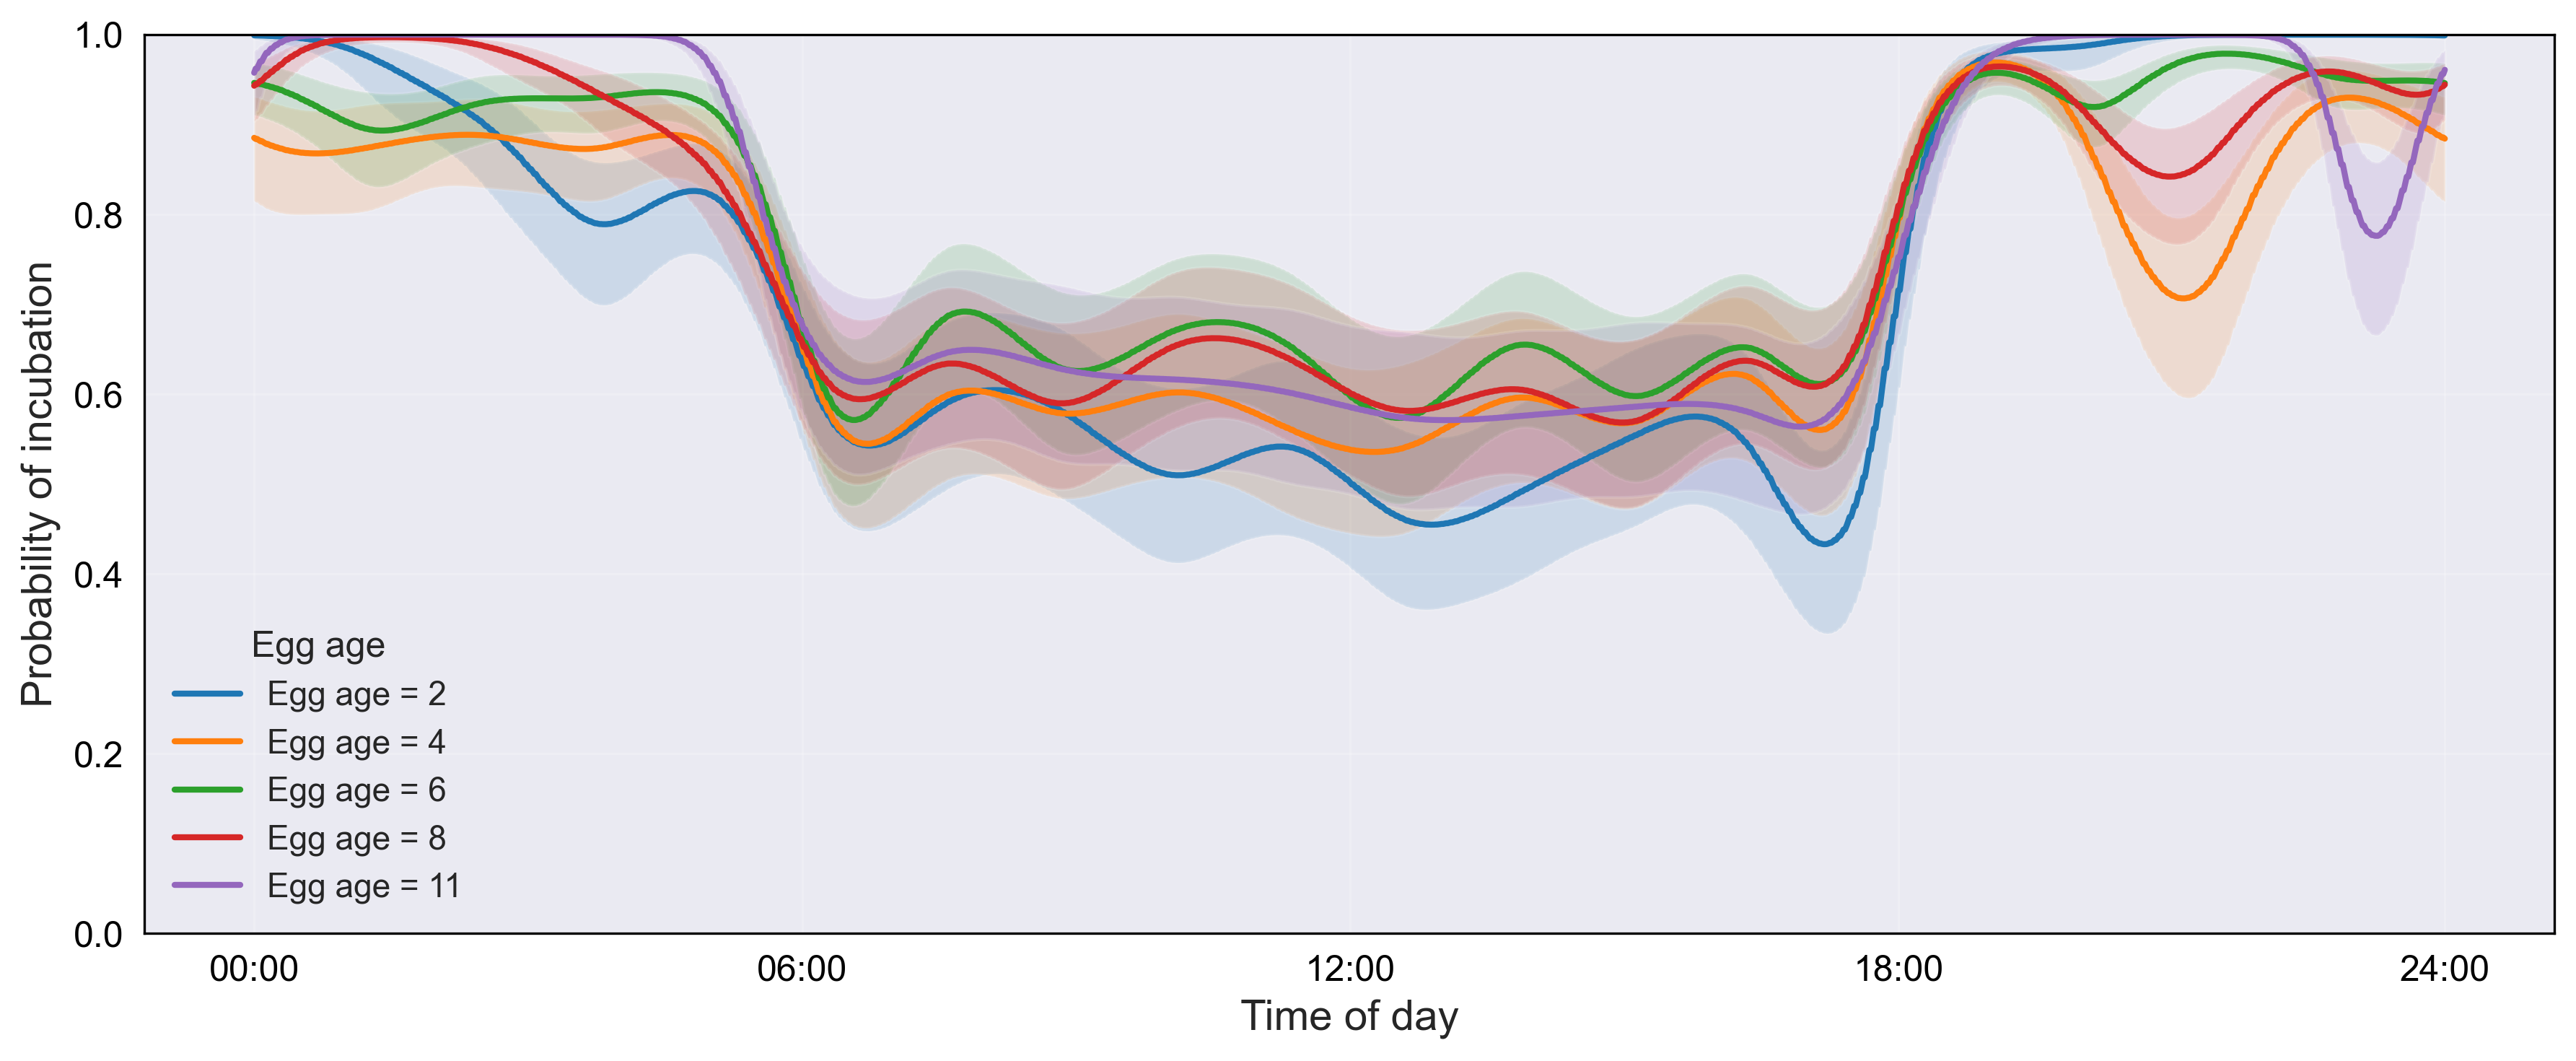

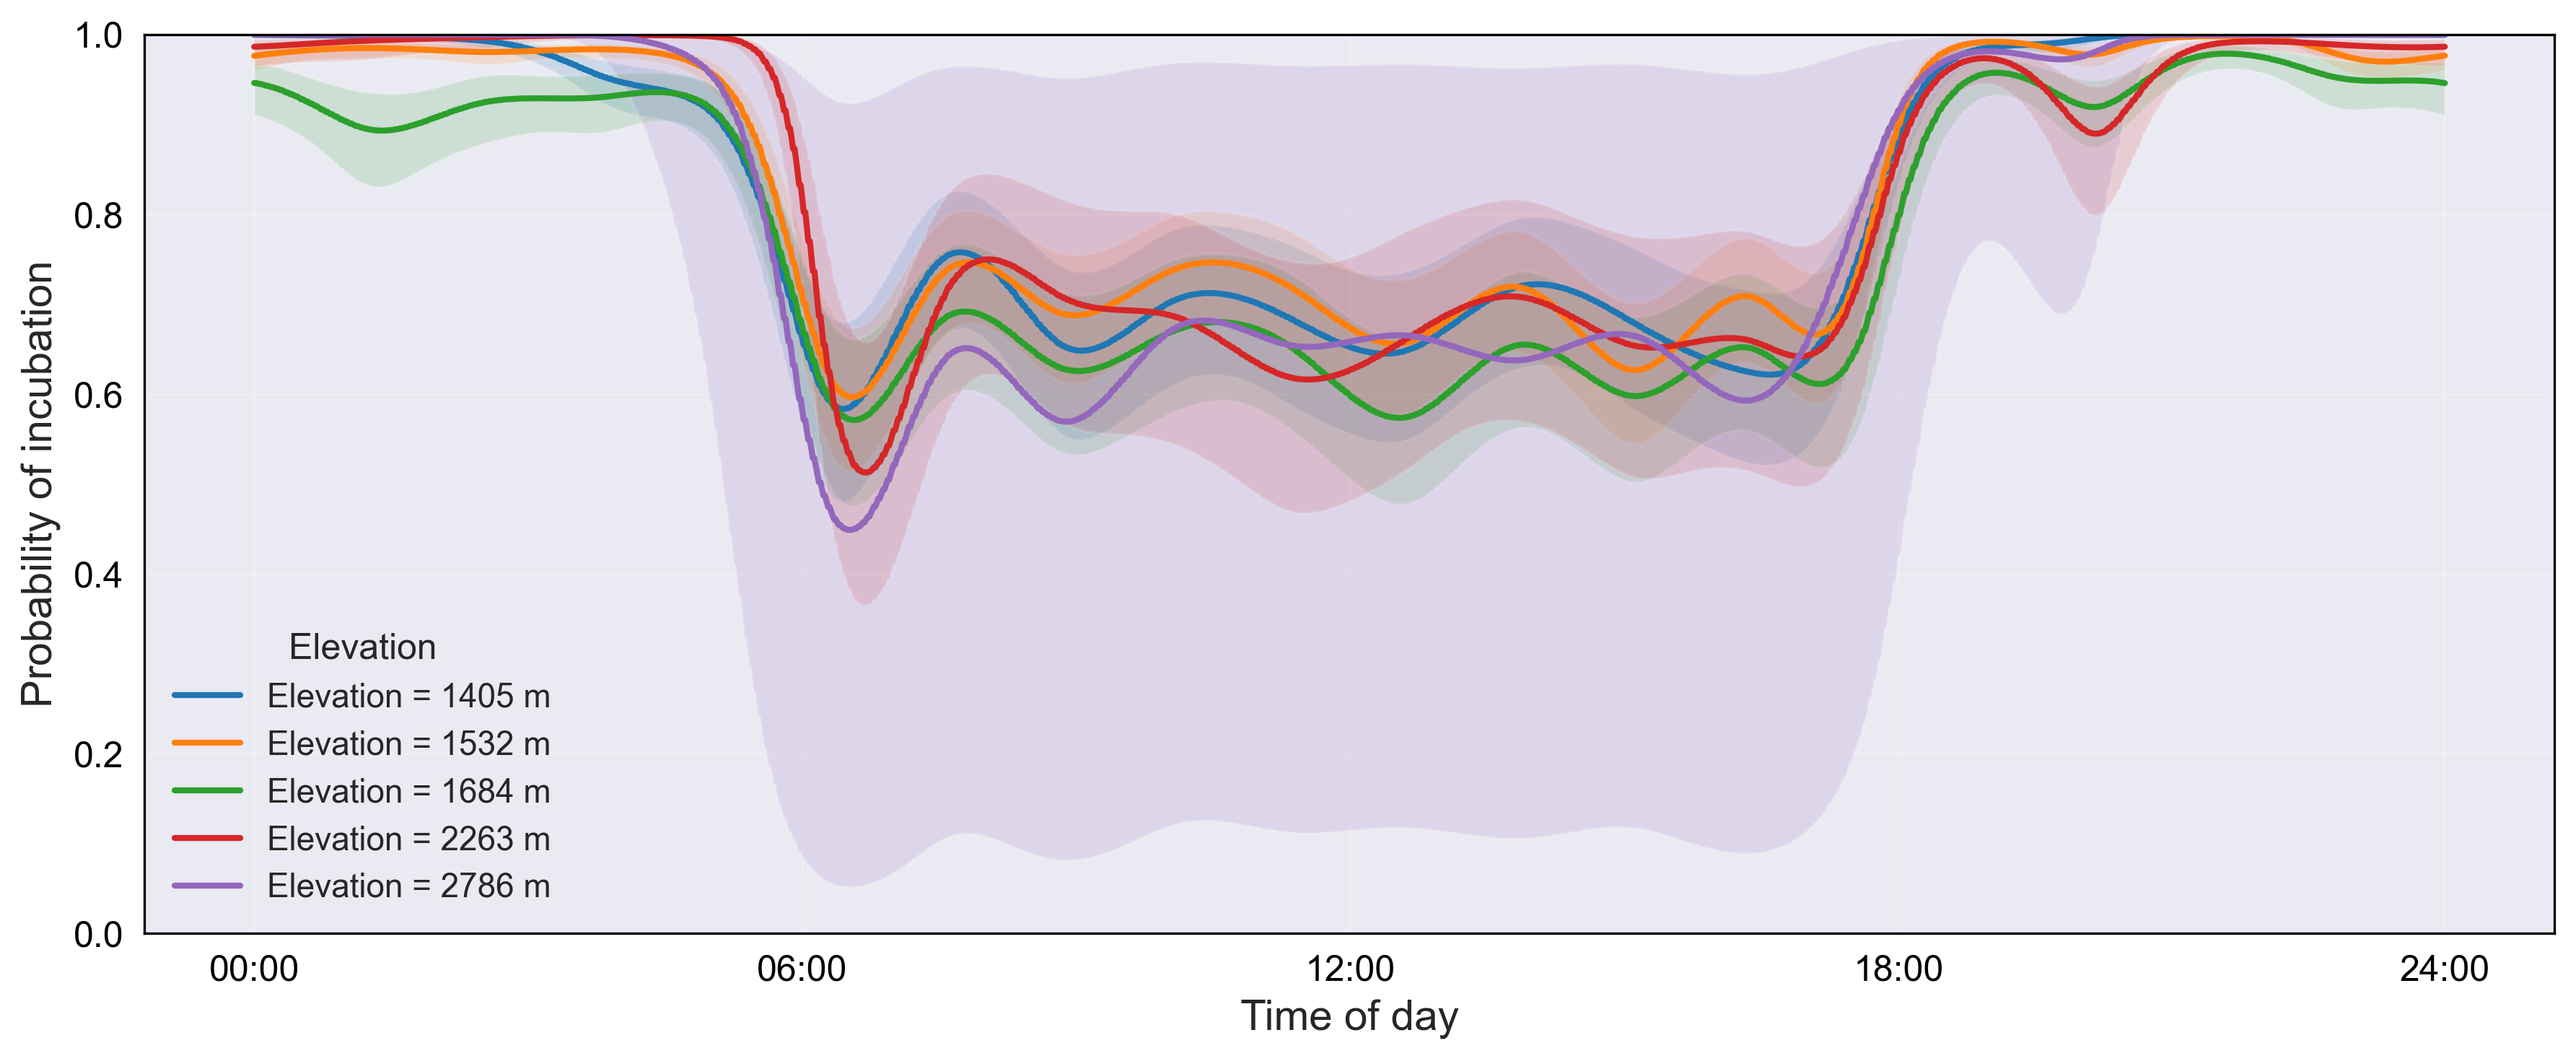

In [30]:
### Curves for different egg ages
plot_line_predictions(
    pred_lines_diaprox,
    group_col="group",
    outpath="Figures/GAMM_lines_eggage.png",
    ylabel_legend="Egg age"
)

### Curves for different elevations
plot_line_predictions(
    pred_lines_elev,
    group_col="group",
    outpath="Figures/GAMM_lines_elevation.png",
    ylabel_legend="Elevation"
)

In [40]:
# ============================================================
# Random-effect diagnostics for preferred GAMM
# model_no_eggmass: s(Nest_ID, bs = "re")
# ============================================================

ro.r("""
library(mgcv)

coef_all <- coef(model_no_eggmass)

re_idx <- grep("^s\\\\(Nest_ID\\\\)", names(coef_all))
re_values <- coef_all[re_idx]

nest_levels <- levels(df_long$Nest_ID)

cat("Random-effect coefficients:", length(re_values), "\\n")
cat("Nest_ID levels:", length(nest_levels), "\\n")

if (length(re_values) != length(nest_levels)) {
  stop("Mismatch: number of random-effect coefficients does not match number of Nest_ID levels")
}

re_df <- data.frame(
  Nest_ID = as.character(nest_levels),
  re_logit = as.numeric(re_values)
)

re_df$odds_multiplier <- exp(re_df$re_logit)
re_df <- re_df[order(re_df$re_logit), ]

cat("\\nMost negative random effects:\\n")
print(head(re_df, 10))

cat("\\nMost positive random effects:\\n")
print(tail(re_df, 10))
""")

with localconverter(ro.default_converter + pandas2ri.converter):
    re_df = ro.conversion.rpy2py(ro.r("re_df"))

re_df["Nest_ID"] = re_df["Nest_ID"].astype(str)

print(re_df.head(10))

Random-effect coefficients: 32 
Nest_ID levels: 32 

Most negative random effects:
                                                    Nest_ID    re_logit
24                  Myioborus_miniatus_TA22a_DB15_processed -1.24751536
20                  Myioborus_miniatus_TA13a_EJ15_processed -1.12133196
16                 Myioborus_miniatus_TA04b_RVA14_processed -0.90947120
11      Myioborus_miniatus_SP2b_DOR09_EGG_processed_soloegg -0.38033056
10      Myioborus_miniatus_SP2a_DOR09_EGG_processed_soloegg -0.33530473
6      Myioborus_melanocephalus_W1b_JAB08_processed_soloegg -0.22578675
3  Myioborus_melanocephalus_w1a_nap08_EGG_processed_soloegg -0.12399149
1        Myioborus_melanocephalus_TU1a_DOR08_NEST_processed -0.12399149
31                 Myioborus_miniatus_TA50_ROAD15_processed -0.11384481
2  Myioborus_melanocephalus_W1a_JAB08_EGG_processed_soloegg -0.09225091
   odds_multiplier
24       0.2872175
20       0.3258455
16       0.4027371
11       0.6836354
10       0.7151201
6        0.

In [41]:
nest_info = (
    df_gamm[["Nest_ID", "Especie", "Estacion", "Elevacion"]]
    .copy()
    .drop_duplicates(subset="Nest_ID")
)

nest_info["Nest_ID"] = nest_info["Nest_ID"].astype(str)

re_df_info = re_df.merge(
    nest_info,
    on="Nest_ID",
    how="left"
)

print("Missing metadata after merge:")
print(re_df_info[["Especie", "Estacion", "Elevacion"]].isna().sum())

top3_neg_info = re_df_info.sort_values("re_logit").head(3)
top3_pos_info = re_df_info.sort_values("re_logit").tail(3)

print("\nTop 3 most negative random effects:")
print(top3_neg_info[["Nest_ID", "re_logit", "odds_multiplier", "Especie", "Estacion", "Elevacion"]])

print("\nTop 3 most positive random effects:")
print(top3_pos_info[["Nest_ID", "re_logit", "odds_multiplier", "Especie", "Estacion", "Elevacion"]])

negativos = re_df_info[re_df_info["re_logit"] < 0].sort_values("re_logit")

print("\nAll negative random effects:")
print(negativos[["Nest_ID", "re_logit", "odds_multiplier", "Especie", "Estacion", "Elevacion"]])

Missing metadata after merge:
Especie      0
Estacion     0
Elevacion    0
dtype: int64

Top 3 most negative random effects:
                                    Nest_ID  re_logit  odds_multiplier  \
0   Myioborus_miniatus_TA22a_DB15_processed -1.247515         0.287218   
1   Myioborus_miniatus_TA13a_EJ15_processed -1.121332         0.325845   
2  Myioborus_miniatus_TA04b_RVA14_processed -0.909471         0.402737   

              Especie Estacion  Elevacion  
0  Myioborus_miniatus   Tatama     1570.0  
1  Myioborus_miniatus   Tatama     1677.0  
2  Myioborus_miniatus   Tatama     1513.0  

Top 3 most positive random effects:
                                              Nest_ID  re_logit  \
29           Myioborus_miniatus_TA26b_MCD14_processed  0.458183   
30           Myioborus_miniatus_TA23b_RVA14_processed  0.539403   
31  Myioborus_miniatus_SPR01_JCB09_EGG_processed_s...  0.621930   

    odds_multiplier             Especie   Estacion  Elevacion  
29         1.581199  Myioborus_m

In [42]:
print("re_df Nest_ID examples:")
print(re_df["Nest_ID"].head(10).tolist())

print("\ndf_gamm Nest_ID examples:")
print(df_gamm["Nest_ID"].drop_duplicates().head(10).tolist())

print("\nNumeric-only Nest_ID values in re_df:")
print(re_df[re_df["Nest_ID"].str.fullmatch(r"\d+")])

re_df Nest_ID examples:
['Myioborus_miniatus_TA22a_DB15_processed', 'Myioborus_miniatus_TA13a_EJ15_processed', 'Myioborus_miniatus_TA04b_RVA14_processed', 'Myioborus_miniatus_SP2b_DOR09_EGG_processed_soloegg', 'Myioborus_miniatus_SP2a_DOR09_EGG_processed_soloegg', 'Myioborus_melanocephalus_W1b_JAB08_processed_soloegg', 'Myioborus_melanocephalus_w1a_nap08_EGG_processed_soloegg', 'Myioborus_melanocephalus_TU1a_DOR08_NEST_processed', 'Myioborus_miniatus_TA50_ROAD15_processed', 'Myioborus_melanocephalus_W1a_JAB08_EGG_processed_soloegg']

df_gamm Nest_ID examples:
['Myioborus_melanocephalus_TU1a_DOR08_NEST_processed', 'Myioborus_melanocephalus_W1a_JAB08_EGG_processed_soloegg', 'Myioborus_melanocephalus_W1a_wjm08_processed_soloegg', 'Myioborus_melanocephalus_W1b_DOR11_EGG_processed_soloegg', 'Myioborus_melanocephalus_W1b_JAB08_processed_soloegg', 'Myioborus_melanocephalus_W1c_DOR11_EGG_processed_soloegg', 'Myioborus_melanocephalus_w1a_nap08_EGG_processed_soloegg', 'Myioborus_miniatus_SP12b_R

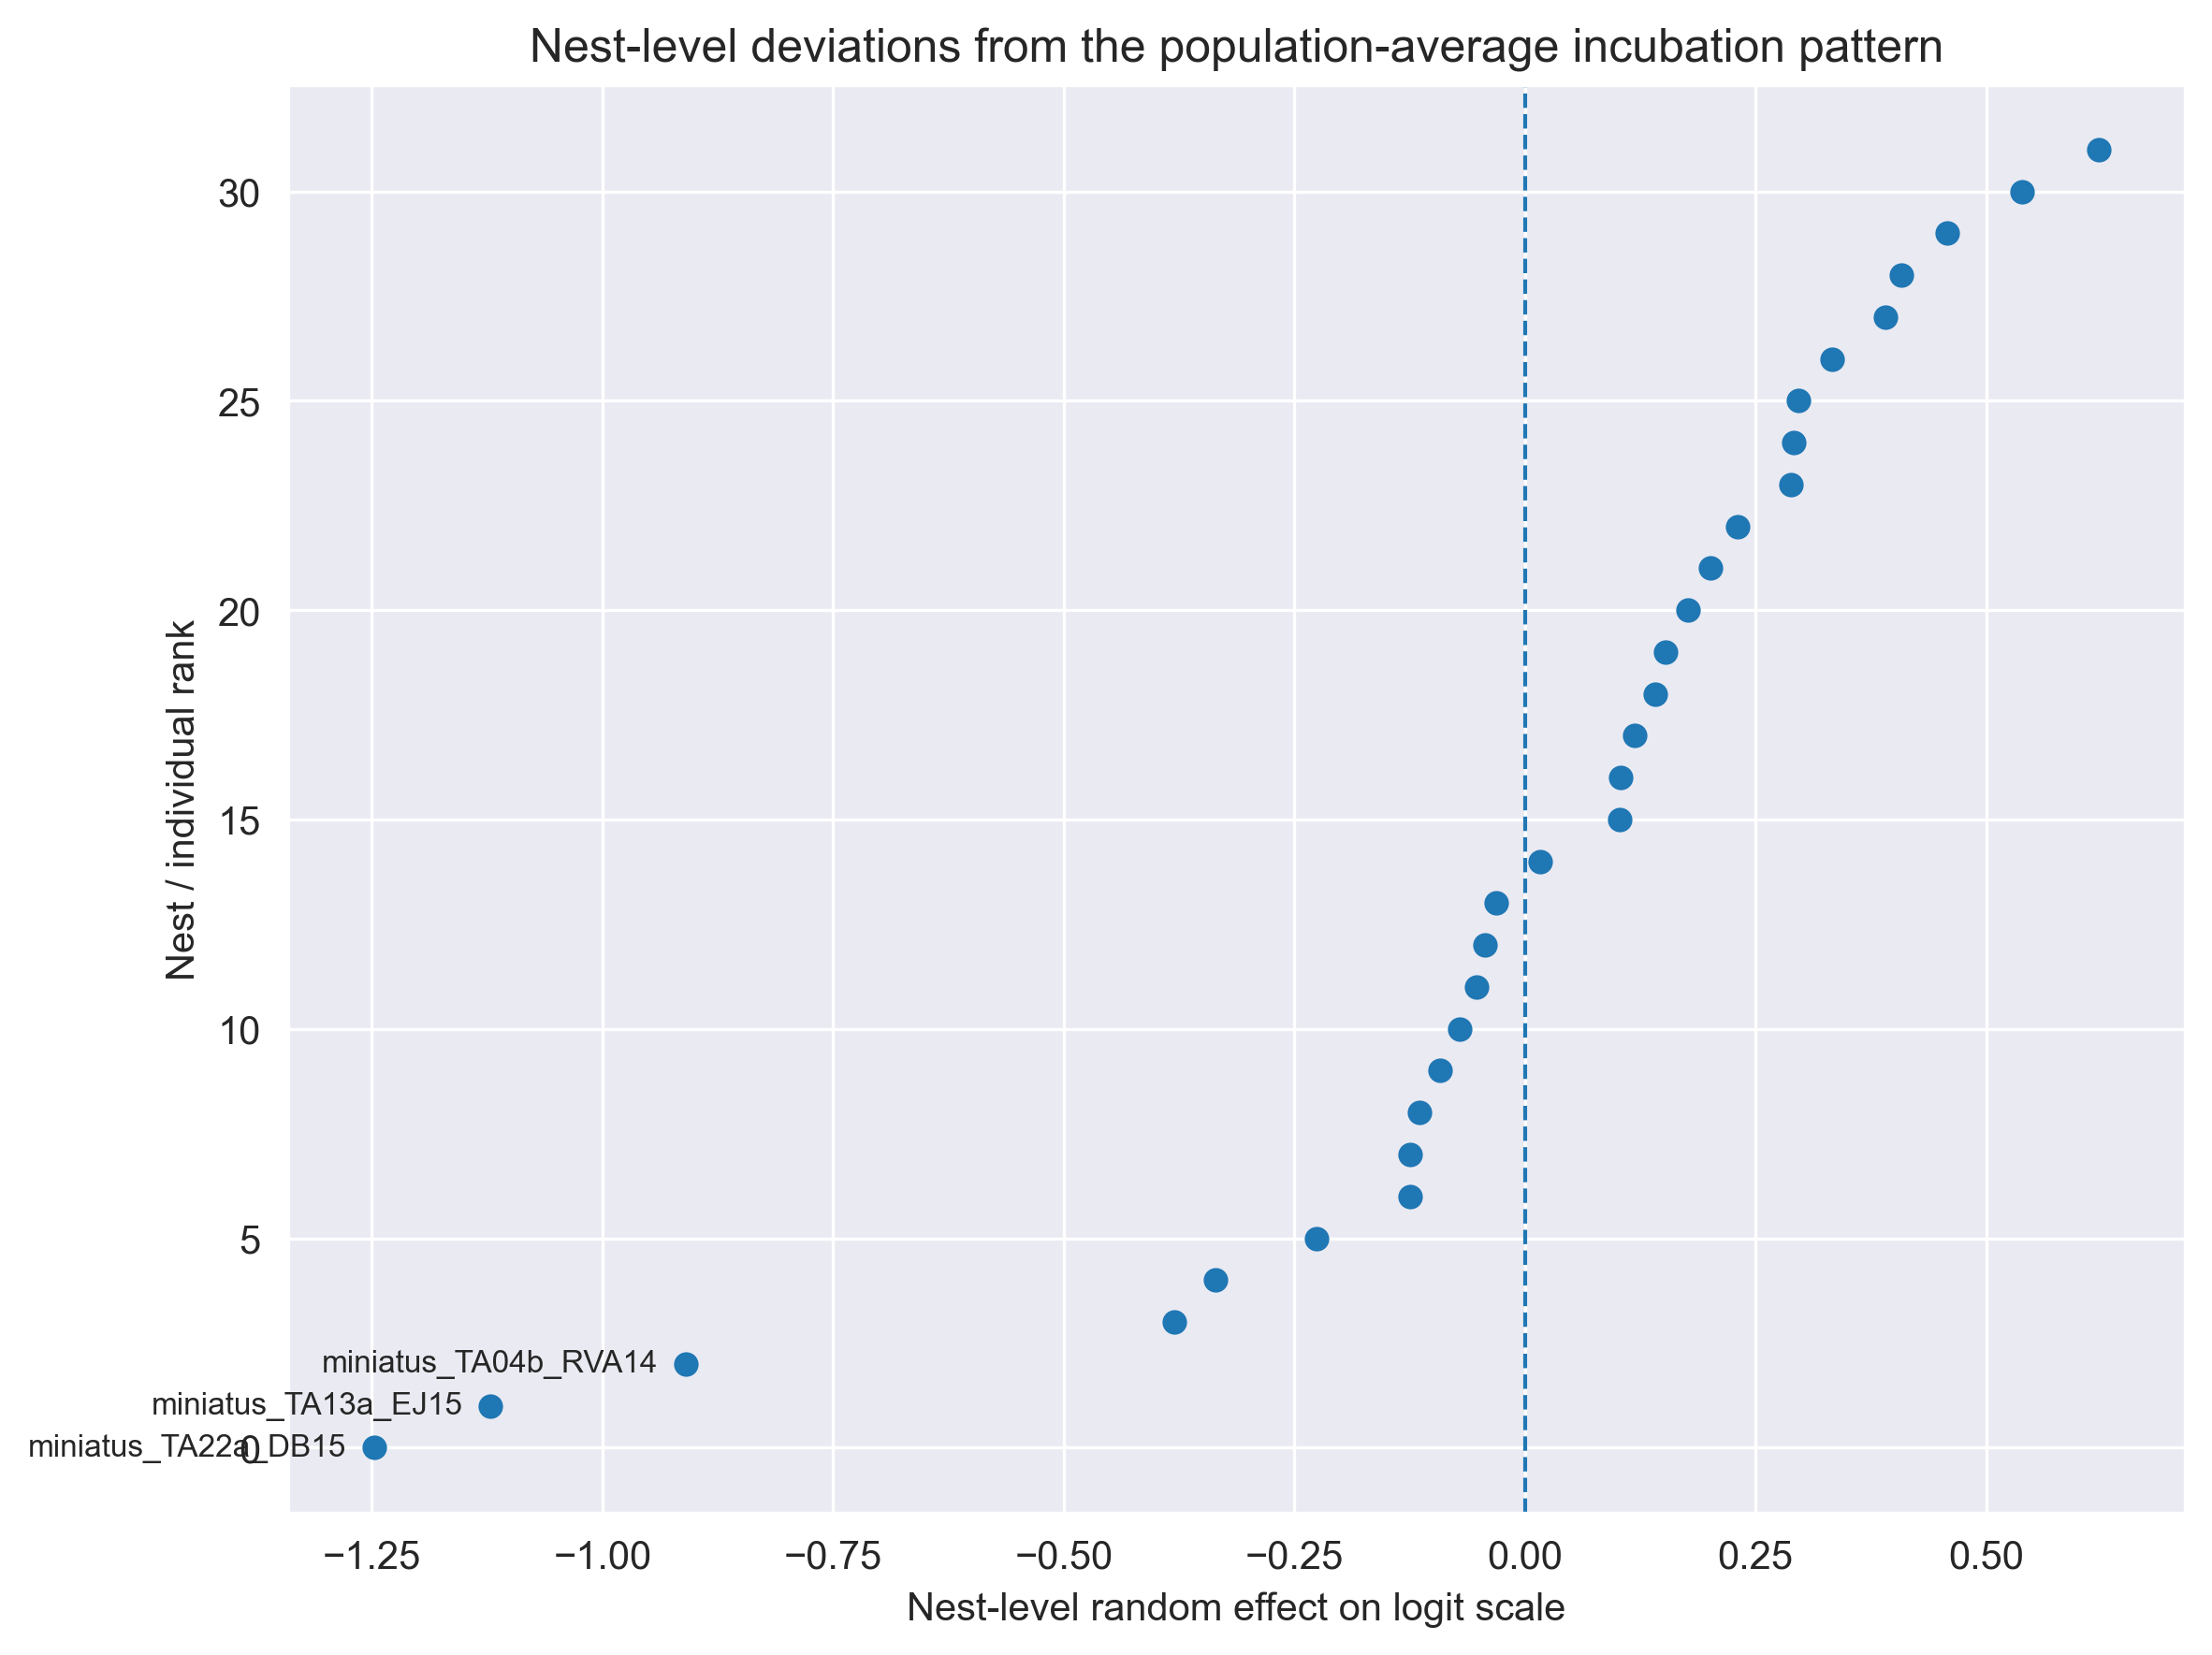

In [43]:
# ============================================================
# Plot nest-level random effects and label the 3 most negative
# ============================================================

re_plot = re_df_info.sort_values("re_logit").reset_index(drop=True)
re_plot["rank"] = np.arange(len(re_plot))

top3_neg_plot = re_plot.nsmallest(3, "re_logit")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

ax.scatter(
    re_plot["re_logit"],
    re_plot["rank"],
    s=28
)

ax.axvline(0, linestyle="--", linewidth=1)

for _, row in top3_neg_plot.iterrows():
    label = row["Nest_ID"].replace("Myioborus_", "").replace("_processed_soloegg", "").replace("_processed", "")
    ax.text(
        row["re_logit"] - 0.03,
        row["rank"],
        label,
        fontsize=8,
        ha="right",
        va="center"
    )

ax.set_xlabel("Nest-level random effect on logit scale")
ax.set_ylabel("Nest / individual rank")
ax.set_title("Nest-level deviations from the population-average incubation pattern")

plt.tight_layout()
plt.savefig(
    "Figures/random_effects_Nest_ID_model_no_eggmass_top3_negative.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()

The nest-level random effects confirm that meaningful heterogeneity remains after accounting for time of day, egg age, and elevation. Some nests are consistently more incubating than the population-average curve would predict, whereas others are consistently less so, which is exactly why nest identity is retained as a random effect rather than treated as nuisance noise.

## Final synthesis

**English**

Supplementary 3 shows that the daily rhythm of incubation is flexible rather than fixed, and that it changes jointly with developmental stage and elevational context. The GAMM dataset retained 184 complete day-level records and 100,284 observations at 2-minute resolution for *Myioborus melanocephalus* and *Myioborus miniatus*. The preferred model kept the cyclic smooth of time of day, smooths for elevation and egg age, both tensor-product interactions with time of day, and a random effect for nest identity, while explaining 24.2% of the deviance. The model without the egg-mass smooth was slightly better supported than the fuller alternative ($\Delta AIC = 0.38$), which means that egg age and elevation already captured most of the broad ecological structure needed to describe incubation probability through the day. The resulting prediction surfaces and line plots therefore support a dynamic view of incubation: higher and cooler nests, and nests at different egg ages, do not follow the same daily timetable of incubation probability.

Read as an ecological story, the notebook suggests that incubation behaviour is reorganised in time rather than shifted by a single constant amount. The dominant effect is the nonlinear diel cycle, but that rhythm is reshaped by both elevation and egg age, so the same clock time does not imply the same incubation probability across nests or developmental stages. At the same time, the nest-level random effects show that important heterogeneity remains after accounting for those broad gradients, with nest-specific deviations spanning roughly from 0.6 to 2 times the population-average odds of incubation. In other words, the shared environmental pattern is real, but individual nests still depart meaningfully from the average curve, which is exactly why nest identity remains biologically informative in the final model.

**Español**

El Supplementary 3 muestra que el ritmo diario de incubación es flexible y no fijo, y que cambia de manera conjunta con el estado de desarrollo y el contexto altitudinal. El conjunto de datos del GAMM retuvo 184 registros diarios completos y 100,284 observaciones a resolución de 2 minutos para *Myioborus melanocephalus* y *Myioborus miniatus*. El modelo preferido mantuvo el suavizado cíclico de la hora del día, los suavizados de elevación y edad del huevo, las dos interacciones tensoriales con la hora del día y un efecto aleatorio de identidad del nido, explicando 24.2% de la devianza. El modelo sin el suavizado de masa del huevo tuvo un soporte apenas mejor que la alternativa más completa ($\Delta AIC = 0.38$), lo que indica que la edad del huevo y la elevación ya capturaban la mayor parte de la estructura ecológica amplia necesaria para describir la probabilidad de incubación a lo largo del día. Por eso, las superficies de predicción y los gráficos de líneas respaldan una visión dinámica de la incubación: los nidos más altos y más fríos, y los nidos en distintas edades del huevo, no siguen exactamente el mismo horario diario de probabilidad de incubación.

Leído como una historia ecológica, el notebook sugiere que la conducta de incubación se reorganiza en el tiempo más que desplazarse por una sola cantidad constante. El efecto dominante es el ciclo diario no lineal, pero ese ritmo es remodelado tanto por la elevación como por la edad del huevo, de modo que una misma hora del día no implica la misma probabilidad de incubación entre nidos o etapas de desarrollo. Al mismo tiempo, los efectos aleatorios a nivel de nido muestran que todavía queda heterogeneidad importante después de controlar esos gradientes amplios, con desviaciones específicas de nido que abarcan aproximadamente entre 0.6 y 2 veces las probabilidades promedio de incubación en escala de odds. En otras palabras, el patrón ambiental compartido es real, pero los nidos individuales todavía se apartan de manera relevante de la curva promedio, y por eso la identidad del nido sigue siendo biológicamente informativa en el modelo final.

<img src="Figures\Logos\Partners.png" width="800px">